Dieser Code trainiert und evaluiert ein BERT-Modell anhand dieses Datensatzes:

@inproceedings{tonneau-etal-2024-languages,

    title = "From Languages to Geographies: Towards Evaluating Cultural Bias in Hate Speech Datasets",

    author = {Tonneau, Manuel  and
      Liu, Diyi  and
      Fraiberger, Samuel  and
      Schroeder, Ralph  and
      Hale, Scott  and
      Röttger, Paul},
    editor = {Chung, Yi-Ling  and
      Talat, Zeerak  and
      Nozza, Debora  and
      Plaza-del-Arco, Flor Miriam  and
      Röttger, Paul  and
      Mostafazadeh Davani, Aida  and
      Calabrese, Agostina},
    
    booktitle = "Proceedings of the 8th Workshop on Online Abuse and Harms (WOAH 2024)",
    month = jun,
    year = "2024",
    address = "Mexico City, Mexico",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2024.woah-1.23",
    pages = "283--311",
    abstract = "Perceptions of hate can vary greatly across cultural contexts.
    Hate speech (HS) datasets, however, have traditionally been developed by
    language. This hides potential cultural biases, as one language may be
    spoken in different countries home to different cultures. In this work, we
    evaluate cultural bias in HS datasets by leveraging two interrelated
    cultural proxies: language and geography. We conduct a systematic survey
    of HS datasets in eight languages and confirm past findings on their
    English-language bias, but also show that this bias has been steadily
    decreasing in the past few years. For three geographically-widespread
    languages{---}English, Arabic and Spanish{---}we then leverage
    geographical metadata from tweets to approximate geo-cultural contexts by
    pairing language and country information. We find that HS datasets for
    these languages exhibit a strong geo-cultural bias, largely
    overrepresenting a handful of countries (e.g., US and UK for English)
    relative to their prominence in both the broader social media population
    and the general population speaking these languages. Based on these
    findings, we formulate recommendations for the creation of future HS
    datasets.",}


In [ ]:
!pip install transformers==5.16.1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import sklearn.metrics as metrics

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset

import transformers

from transformers import (
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)

print(transformers.__version__)
print(transformers.__file__)

5.16.1
/usr/local/lib/python3.13/dist-packages/transformers/__init__.py


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/de_hf_112024.csv",sep=",",engine="python",on_bad_lines="skip",encoding="utf-8")
df.head()


,text,labels,source,dataset,nb_annotators
0,gleich an die wand stellen und erschiessen..,1.0,Facebook,Bretschneider,2.0
1,nicht dass ich der Grundbotschaft dieses Post'...,0.0,Facebook,Bretschneider,2.0
2,"Das mit dem ""an die Wand stellen und erschiessen""",0.0,Facebook,Bretschneider,2.0
3,"Seit dem ""an die Wand stellen und erschiessen""...",0.0,Facebook,Bretschneider,2.0
4,Ja ja die Kriminelle Heimatpartei FPÖ von Kind...,0.0,Facebook,Bretschneider,2.0


In [ ]:
df=df.dropna(subset=["labels"])

In [ ]:
from sklearn.model_selection import train_test_split
X=df["text"]
y=df["labels"].astype(int)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.1,random_state=42,stratify=y_train)

In [ ]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
#Tokenizer Laden
model_standard="bert-base-german-cased"
tokenizer=AutoTokenizer.from_pretrained(model_standard)

config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/255k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/485k [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True
)

In [ ]:
class HateSpeechDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels.iloc[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)
train_dataset = HateSpeechDataset(train_encodings, y_train)
val_dataset = HateSpeechDataset(val_encodings, y_val)
test_dataset= HateSpeechDataset(test_encodings, y_test)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_standard,
    num_labels=2 #klassenanzahl
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-german-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
#from transformers import TrainingArguments

#Trainingsparameter
training_args = TrainingArguments(
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=50,
    fp16=True
)


In [ ]:
#Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    #compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)
#Modell Training starten
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.469394,0.221219
2,0.403424,0.246809
3,0.192509,0.428603


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6825, training_loss=0.36245538467015975, metrics={'train_runtime': 2108.4256, 'train_samples_per_second': 86.297, 'train_steps_per_second': 5.395, 'total_flos': 5206659452306400.0, 'train_loss': 0.36245538467015975, 'epoch': 3.0})

In [ ]:
pred_output = trainer.predict(val_dataset)
y_val_proba = torch.softmax(torch.tensor(pred_output.predictions), dim=1)[:,1].numpy()
y_valpred = (y_val_proba > 0.5).astype(int)

In [ ]:
with open("bert_ohne_Sequenz.txt", "w") as fd:
    for text, label, proba in zip(X_val, y_val, y_val_proba):
        fd.write(f"Text: {text}\n")
        fd.write(f"Label: {label}\n")
        fd.write(f"Wahrscheinlichkeit Hasskommentar: {proba}\n")
        fd.write("\n"*4)
schwellen = np.arange(0.0, 1.01, 0.01)
beste_schwelle = 0
beste_f1 = 0

for t in schwellen:
    y_pred_t = (y_val_proba > t).astype(int)
    f1 = metrics.f1_score(y_val, y_pred_t)
    if f1 > beste_f1:
        beste_f1 = f1
        beste_schwelle = t
        print("Schwelle: ", beste_schwelle)
        print("F1_score: ", beste_f1)
        print("\n"*4)

print("Beste Schwelle:", beste_schwelle)
print("Bester F1-Score:", beste_f1)

Schwelle:  0.0
F1_score:  0.22163588390501318





Schwelle:  0.01
F1_score:  0.3631656804733728





Schwelle:  0.02
F1_score:  0.4275555555555556





Schwelle:  0.03
F1_score:  0.4671890303623898





Schwelle:  0.04
F1_score:  0.49185496584340516





Schwelle:  0.05
F1_score:  0.5110132158590308





Schwelle:  0.06
F1_score:  0.5268630849220104





Schwelle:  0.07
F1_score:  0.5378151260504201





Schwelle:  0.08
F1_score:  0.5421020282728949





Schwelle:  0.09
F1_score:  0.5505050505050505





Schwelle:  0.1
F1_score:  0.5592233009708738





Schwelle:  0.11
F1_score:  0.5697290152015863





Schwelle:  0.12
F1_score:  0.577807848443843





Schwelle:  0.13
F1_score:  0.5794907088781831





Schwelle:  0.14
F1_score:  0.5874125874125874





Schwelle:  0.15
F1_score:  0.592170818505338





Schwelle:  0.16
F1_score:  0.5947901591895803





Schwelle:  0.17
F1_score:  0.6014705882352941





Schwelle:  0.18
F1_score:  0.6077844311377245





Schwelle:  0.19
F1_score:  0.6124

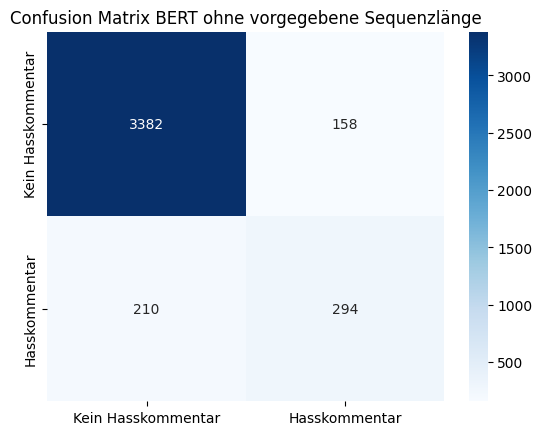

In [ ]:
cm = metrics.confusion_matrix(y_val, y_valpred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar", "Hasskommentar"],
    yticklabels=["Kein Hasskommentar", "Hasskommentar"]
)
plt.title("Validierung Confusion Matrix BERT ohne vorgegebene Sequenzlänge")
plt.show()

In [ ]:
# accuracy
vaccuracy = metrics.accuracy_score(y_val, y_valpred)
# precision
vprecision = metrics.precision_score(y_val, y_valpred)
# recall
vrecall = metrics.recall_score(y_val, y_valpred)
# f1-score
vf1=metrics.f1_score(y_val, y_valpred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_val, y_valpred).ravel()
vspecificity = tn/(tn+fp)
# macro recall
vmacro_recall=metrics.recall_score(y_val, y_valpred, average='macro')
# macro f1-score
vmacro_f1=metrics.f1_score(y_val, y_valpred, average='macro')

In [ ]:
print("Accuracy: ", vaccuracy)
print("Precision: ", vprecision)
print("Recall: ", vrecall)
print("Specificity: ", vspecificity)
print("F1-Score: ", vf1)
print("Macro Recall: ", vmacro_recall)
print("Macro F1-Score: ", vmacro_f1)

Accuracy:  0.9090009891196835
Precision:  0.6504424778761062
Recall:  0.5833333333333334
Specificity:  0.9553672316384181
F1-Score:  0.6150627615062761
Macro Recall:  0.7693502824858758
Macro F1-Score:  0.7817321659466322


In [ ]:
trainer.save_model(
    "/content/drive/MyDrive/Colab Notebooks/BERT_model_sequenz"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/Colab Notebooks/BERT_model_sequenz"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Colab Notebooks/BERT_model_sequenz/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/BERT_model_sequenz/tokenizer.json')

In [ ]:
pred_output = trainer.predict(test_dataset)
y_test_proba = torch.softmax(torch.tensor(pred_output.predictions), dim=1)[:,1].numpy()
y_pred = (y_test_proba > 0.5).astype(int)

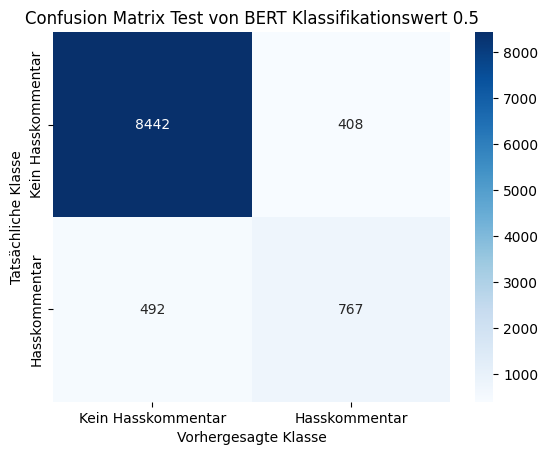

In [ ]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title("Confusion Matrix Test von BERT Klassifikationswert 0.5")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [ ]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [ ]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.9109704223958849
Precision:  0.6527659574468085
Recall:  0.6092136616362193
Specificity:  0.9538983050847457
F1-Score:  0.6302382908792111
Macro Recall:  0.7815559833604825
Macro F1-Score:  0.7898155017149092


In [ ]:
pred_output = trainer.predict(test_dataset)
y_test_proba = torch.softmax(torch.tensor(pred_output.predictions), dim=1)[:,1].numpy()
y_pred = (y_test_proba > beste_schwelle).astype(int)

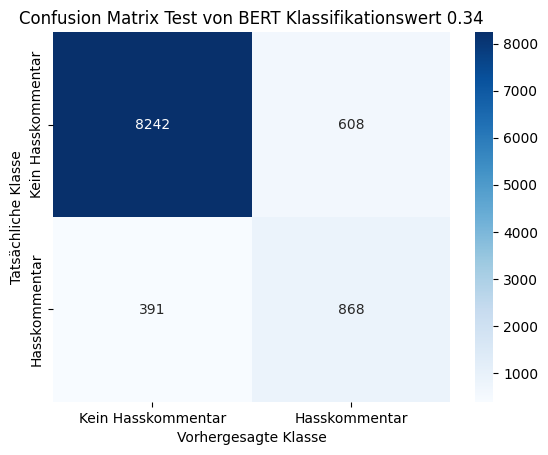

In [ ]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title(f"Confusion Matrix Test von BERT Klassifikationswert {beste_schwelle}")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [ ]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [ ]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.9011771688594322
Precision:  0.5880758807588076
Recall:  0.6894360603653693
Specificity:  0.9312994350282486
F1-Score:  0.6347349177330895
Macro Recall:  0.810367747696809
Macro F1-Score:  0.7887968474154208
